## Tutorial: Fast self-forced trajectories

This tutorial is based on https://github.com/BlackHolePerturbationToolkit/FastEMRIWaveforms/blob/master/examples/Trajectory_tutorial.ipynb by Christian Chapman-Bird, Lorenzo Speri and Maxime Pigou and https://github.com/BlackHolePerturbationToolkit/FastEMRIWaveforms/blob/master/examples/Tutorial_FrequencyDomain_Waveforms.ipynb by Michael Katz and Lorenzo Speri. More details on FEW trajectories and waveforms can be found there. 

In [1]:
# Standard library
import time

# Third-party
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# LISA / plotting helpers
from pastamarkers import markers
# from lisatools.sensitivity import get_sensitivity if you have lisatools installed

# FEW package
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.trajectory.ode.base import get_ode_properties
from few.utils.utility import get_p_at_t
from few.utils.constants import YRSID_SI
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform

## Vacuum trajectories

#### Parameter conventions

FEW constructs trajectories by integrating the equations of motion of the compact binary; these are a system of ordinary differential equations (ODEs) that describe the evolution of the following parameters:

| Parameter    | Definition |
| :--------: | ------- |
| $p$  | (Dimensionless) semi-latus rectum|
| $e$ | Eccentricity |
| $x_I$    | Cosine of the inclination of the orbital plane|
| $\Phi_\phi$    | Azimuthal orbital phase |
| $\Phi_\theta$    | Polar orbital phase|
| $\Phi_r$    | Radial orbital phase|

The ODE system can be integrated efficiently with adaptive Runge-Kutta techniques. These solvers obtain trajectories by integrating the right-hand side (RHS) of the ODE with respect to a time parameter.

### Stock trajectory models

In order to handle the necessary information for evaluating the RHS of the ODE, FEW defines ODE classes. The following stock options are available:

| Model    | Features |  Notes |
| :--------: | ------- | ------- |
| KerrEccEqFlux | Adiabatic; equatorial eccentric inspiral with spinning primary| Our most up-to-date model |
| SchwarzEccFlux  | Adiabatic; inspiral with non-spinning primary | An older model (currently outdated) |
| PN5    | Post-Newtonian; eccentric inclined inspirals with spinning primary | Most complete model, but inaccurate for larger $e$ and/or lower $p$|


#### Obtaining the right-hand side of the trajectory ODE

As an example, let's examine the SchwarzEccFlux model:

In [9]:
from few.trajectory.ode import KerrEccEqFlux

rhs = KerrEccEqFlux()

Before evaluating the RHS, we must first define the parameters of the system that remain fixed during an inspiral. At adiabatic order, these are the component masses ($m_1$ and $m_2$) and the dimensionless spin parameter of the primary ($a$):

In [10]:
m1 = 1e6  # Solar masses
m2 = 1e1  # Solar masses
a = 0.0  # For a Schwarzschild inspiral, the spin parameter is zero

rhs.add_fixed_parameters(m1, m2, a)

We can then access the ODE derivatives:

In [11]:
p = 10.0
e = 0.3
x = 1.0  # Schwarzschild inspiral is equatorial by definition

pdot, edot, xIdot, Omega_phi, Omega_theta, Omega_r = rhs([p, e, x])
pdot, edot, xIdot, Omega_phi, Omega_theta, Omega_r

(np.float64(-0.017771733850639584),
 np.float64(-0.0007792825338686243),
 np.float64(0.0),
 np.float64(0.028647063536752972),
 np.float64(0.028647063536752972),
 np.float64(0.018040932375307846))

FEW integrates trajectories on the radiation-reaction timescale $t_\mathrm{rr} = t \nu$, where $\nu = \mu / M$ is the mass ratio of the system (for $\mu$ and $M$ as the reduced and total mass respectively). The RHS of the ODE is therefore defined such that the $(\dot{p}, \dot{e}, \dot{x}_I)$ are scaled by $\nu^{-1}$.

#### Checking the properties of an ODE system

The ODE class also defines a number of properties that describe the physical and systematic assumptions of the model:

In [12]:
from few.trajectory.ode.base import get_ode_properties

get_ode_properties(rhs)

{'convert_Y': False,
 'equatorial': True,
 'circular': False,
 'supports_ELQ': True,
 'background': 'Kerr',
 'separatrix_buffer_dist': 0.002,
 'nparams': 6,
 'flux_output_convention': 'pex',
 'separatrix_buffer_dist_grid': 0.001}

#### Checking the model domain of validity

ODE models that interpolate over pre-computed data can only be evaluated over a finite domain. The bounds of this domain can be verified with class methods. For instance, to check the maximum eccentricity at $p=10$ for this model, we write

In [13]:
rhs.max_e(10.)

0.8491305415768282

### Trajectory evaluation

#### The EMRIInspiral class

Trajectories are evaluated using the `EMRIInspiral` class, which interfaces with the underlying integrator classes and methods in order to integrate the trajectory from its initial conditions until either the maximum alloted duration elapses or pre-determined stopping conditions are satisfied.

The `EMRIInspiral` class offers a number of features that can be adjusted according to the desired output. We will demonstrate these below, working with the `KerrEccEqFlux` trajectory model as an example.

In [14]:
from few.trajectory.inspiral import EMRIInspiral

In [15]:
# You can also instantiate this as EMRIInspiral(func="KerrEccEqFlux") to save an import.
traj_model = EMRIInspiral(func=KerrEccEqFlux)

In [16]:
m1 = 1e6
m2 = 1e2
a = 0.9  # This model supports a spinning primary compact object
p0 = 10.0
e0 = 0.8
xI0 = 1.0  # +1 for prograde, -1 for retrograde inspirals

T = 4.0  # duration of trajectory in years (as defined by few.utils.constants.YRSID_SI)

traj_pars = [m1, m2, a, p0, e0, xI0]

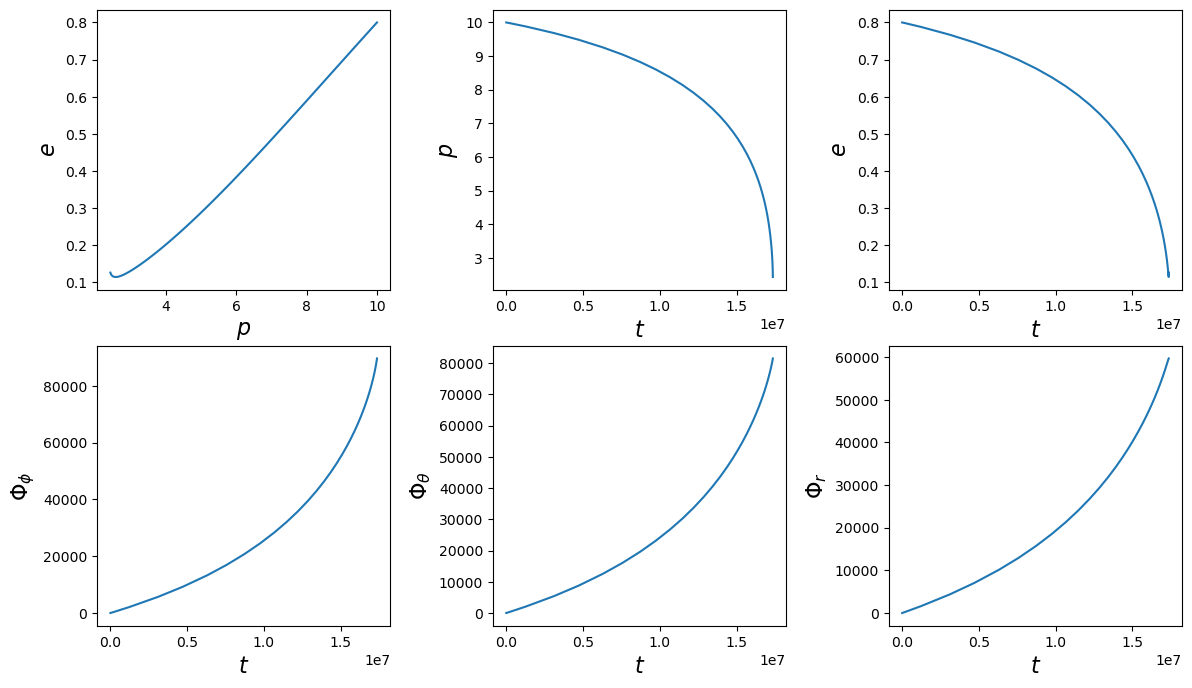

In [17]:
import matplotlib.pyplot as plt
import numpy as np

t, p, e, xI, Phi_phi, Phi_theta, Phi_r = traj_model(*traj_pars, T=T)

fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.35)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [r"$e$", r"$p$", r"$e$", r"$\Phi_\phi$", r"$\Phi_\theta$", r"$\Phi_r$"]
xlabels = [r"$p$", r"$t$", r"$t$", r"$t$", r"$t$", r"$t$"]
ys = [e, p, e, Phi_phi, Phi_theta, Phi_r]
xs = [p, t, t, t, t, t]

for i, (ax, x, y, xlab, ylab) in enumerate(zip(axes, xs, ys, xlabels, ylabels)):
    ax.plot(x, y)
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

### Trajectory stopping conditions

In principle, the inspiral trajectory continues until $p$ intersects with the separatrix, $p_\mathrm{sep}(a, e, x_I)$. However, FEW truncates the inspiral at the buffer point $p_\mathrm{stop} = p_\mathrm{sep} + \Delta p$ for numerical stability, performing a root-finding operation to place the last trajectory point within $\sim 10^{-8}$ of $p_\mathrm{stop}$. 

#### Output for a requested time duration

By using the keyword argument `T`, the trajectory to be computed until it reaches a desired time (in years).

In [18]:
import matplotlib.pyplot as plt
import numpy as np

T = 0.1  # duration of trajectory in years (as defined by few.utils.constants.YRSID_SI)

t_trunc, p_trunc, e_trunc, xI_trunc, Phi_phi_trunc, Phi_theta_trunc, Phi_r_trunc = traj_model(*traj_pars, T=T)

t[-1], t_trunc[-1]

(np.float64(17366327.48432057), np.float64(3155814.9763545603))

#### Get $p_0$ based on desired duration of trajectory

If you have a desired length of trajectory to analyze, this function will give you the value of $p_0$ that corresponds to the proper evolution time.

In [24]:
from few.utils.utility import get_p_at_t

traj = EMRIInspiral(func=SchwarzEccFlux)

# Set initial parameters
m1 = 1e6
m2 = 5e1
a=0.0
e0 = 0.7
xI0=1.0

traj_args = [m1, m2, a, e0, xI0]
traj_kwargs = {}

t_out = 1.5
# Run trajectory
p0_new = get_p_at_t(
    traj,
    t_out,
    traj_args,
    #index_of_a=2, # specifies the position of the index as it appears in the argument of traj
    #index_of_p=3,
    #index_of_e=4,
    #index_of_x=5,
    traj_kwargs=traj_kwargs,
    xtol=1e-15,
    rtol=1e-15,
    bounds=None,
)

print(
    "p0_new = {} will create a waveform that is {} years long, given the other input parameters.".format(
        p0_new, t_out
    )
)

p0_new = 13.05941726854163 will create a waveform that is 1.5 years long, given the other input parameters.


## Vacuum waveforms

In [10]:
traj = EMRIInspiral(func=KerrEccEqFlux)

# time domain
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux", 
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True
)

# parameters
M = 1e6
mu = 1e2
p0 = 12.0
e0 = 0.4
a=0.9
theta = np.pi/3  # polar viewing angle
phi = np.pi/4  # azimuthal viewing angle

x0 = 1.0  # will be ignored in Schwarzschild waveform
qK = np.pi/3  # polar spin angle
phiK = np.pi/3  # azimuthal viewing angle
qS = np.pi/3  # polar sky angle
phiS = np.pi/3  # azimuthal viewing angle
dist = 1.0  # distance
# initial phases
Phi_phi0 = np.pi/3
Phi_theta0 = 0.0
Phi_r0 = np.pi/3

Tobs = 1.0 # observation time, if the inspiral is shorter, the it will be zero padded 
dt = 10.0 # time interval
eps = 1e-2 # mode content percentage
mode_selection = [(2,2,0)]

waveform_kwargs = {
    "T": Tobs,
    "dt": dt,
# you can uncomment the following lines if you want to show a specific mode or modes
#     "mode_selection" : mode_selection,
#     "include_minus_m": True
    "eps": eps,
    
}

# get the initial p0 
p0 = get_p_at_t(
    traj,
    Tobs*0.99,
    [M, mu, 0.0, e0, 1.0],
    index_of_p=3,
    index_of_a=2,
    index_of_e=4,
    index_of_x=5,
    traj_kwargs={},
    xtol=2e-12,
    rtol=8.881784197001252e-16,
    bounds=None,
)


emri_injection_params = [
    M,  
    mu,
    a, 
    p0, 
    e0, 
    x0,
    dist, 
    qS,
    phiS,
    qK, 
    phiK, 
    Phi_phi0, 
    Phi_theta0, 
    Phi_r0
]

In [12]:
# create time domain signal
data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs)

# # take the FFT of the plus polarization and shift it
# fft_TD = np.fft.fftshift(np.fft.fft(data_channels_td[0])) * dt
# freq = np.fft.fftshift(np.fft.fftfreq(len(data_channels_td[0]) , dt))

# # define the positive frequencies
# positive_frequency_mask = (freq>=0.0)

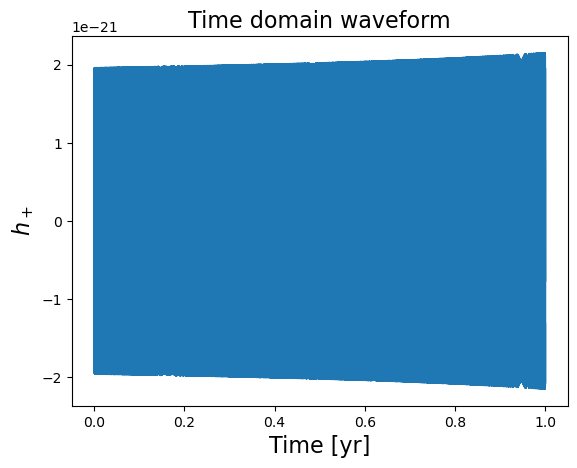

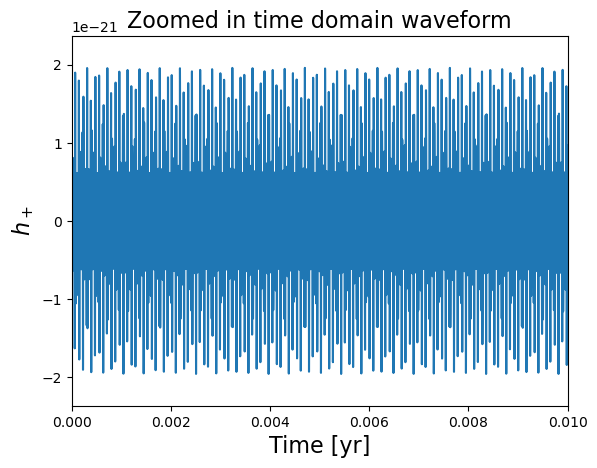

In [16]:
# plot the waveform data_channels_td in the time domain t = np.linspace(0, Tobs, len(data_channels_td[0]))
plt.figure()
plt.plot(np.linspace(0, Tobs, len(data_channels_td[0])), data_channels_td[0])
plt.xlabel("Time [yr]", fontsize=16)
plt.ylabel(r"$h_+$", fontsize=16)
plt.title("Time domain waveform", fontsize=16)
plt.show()

# plot also a shorter segment of the waveform to show the oscillations
plt.figure()
plt.plot(np.linspace(0, Tobs, len(data_channels_td[0])), data_channels_td[0])
plt.xlim(0, 0.01)
plt.xlabel("Time [yr]", fontsize=16)
plt.ylabel(r"$h_+$", fontsize=16)
plt.title("Zoomed in time domain waveform", fontsize=16)
plt.show()

## Environmental effects

### Modifying trajectory models

In cases where the desired trajectory model can be expressed as a function of one that is supported out-of-the-box, the inbuilt model can be subclassed and supplemented as required by defining the `modify_rhs` method. This method takes as input the
current system state and the corresponding derivatives produced by the model, which can then be modified as required. 

This method does not support a return argument for efficiency; the content of the first argument `derivs` should be modified in-place.

In [20]:
from few.trajectory.ode.flux import KerrEccEqFlux


class ModifiedKerrEccEqFlux(KerrEccEqFlux):
    def modify_rhs(self, ydot, y):
        # in-place modification of the derivatives by a multiplicative factor
        ydot[0] *= 1 + self.additional_args[0]


m1 = 1e6
m2 = 1e2
a = 0.7
p = 10.0
e = 0.3
xI = 1.0

additional_args = [
    0.01,
]

# Example usage
original_ode = KerrEccEqFlux()
original_ode.add_fixed_parameters(m1, m2, a)

modified_ode = ModifiedKerrEccEqFlux()
modified_ode.add_fixed_parameters(m1, m2, a, additional_args)

original_ode([p, e, xI])[0], modified_ode([p, e, xI])[0]

(np.float64(-0.011514135697943613), np.float64(-0.011629277054923049))

When calling a trajectory, the `additional_args` attribute of the ODE class will be populated with any positional arguments following $x_I$:

/var/folders/7j/mmw81qxs79d3tmffc_nyrhj00000gq/T/ipykernel_86295/1474506310.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ydot[0] *= 1 + self.additional_args[0]


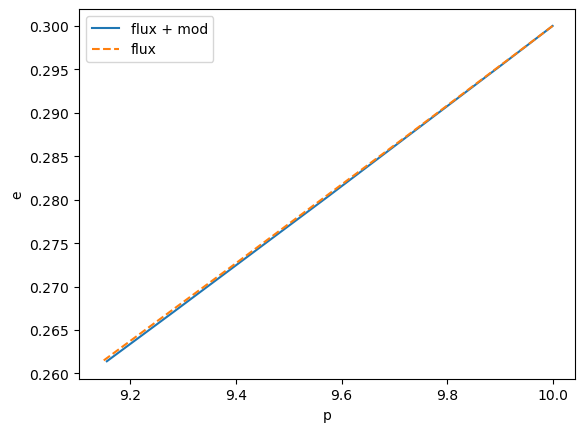

In [ ]:
m1 = 1e6
m2 = 1e2
a = 0.7
p0 = 10.0
e0 = 0.3
xI0 = 1.0

additional_args = [
    0.01,
]

traj_modified = EMRIInspiral(func=ModifiedKerrEccEqFlux)
# t, p, e, xI, Phi_phi, Phi_theta, Phi_r 
flux_modified = traj_modified(m1, m2, a, p0, e0, xI0, additional_args, T=T, dt=10.0)

traj = EMRIInspiral(func=KerrEccEqFlux)
flux = traj(m1, m2, a, p0, e0, xI0, T=T, dt=10.0)

plt.plot(flux[1], flux[2], label="flux + mod")
plt.plot(flux_modified[1], flux_modified[2], label="flux", ls="--")
plt.ylabel("e")
plt.xlabel("p")

plt.legend()
plt.show()

The flux-based stock models perform interpolation to obtain the integral fluxes $\dot{E}$, $\dot{L}_{z}$, and then apply a Jacobian transformation in order to obtain $\dot{p}$, $\dot{e}$ if these are the variables of integration (and they are by default). In some cases, the user may wish to adjust $\dot{E}$, $\dot{L}_z$ directly if the modifications desired are more easily computed in this parameterisation. This can be achieved similarly to what was shown above, but with the `modify_rhs_before_Jacobian` method.

### Environment: accretion disk, Interaction: type-I migration

From
$$ \frac{dL}{dt} =\frac{dL}{dp}\frac{dp}{dt} = \dot{L}_{\rm gw} + \dot{L}_{\rm disk}$$
we have
$$\left.\frac{dp}{dt}\right|_{\rm disk} - \left.\frac{dp}{dt}\right|_{\rm vacuum} = \dot{L}_{\rm disk} / \frac{dL}{dp}  = A_{\rm disk} (r/10 M)^{n_{\rm disk}} \dot{L}_{\rm gw}/ \frac{dL}{dp} $$


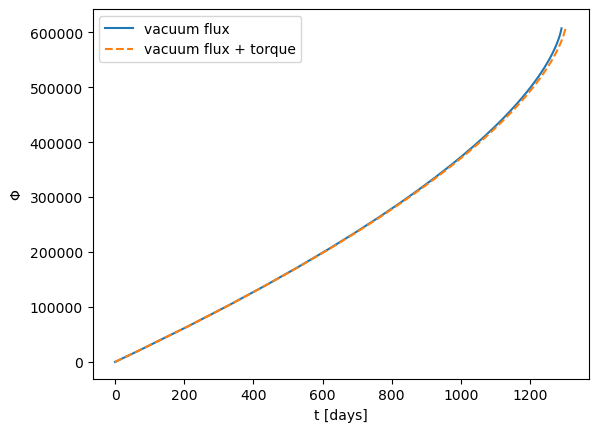

In [8]:
# Dissipation of energy and angular momentum due to migration torques in an accretion disk
# following Eq(2.2) of https://dx.doi.org/10.1103/PhysRevX.13.021035

class KerrEccEqFluxEnvironment(KerrEccEqFlux):
    def modify_rhs(self, ydot, y):
        # accretion disk torque 
        LdotAcc = (
            self.additional_args[0] # dimensionless accretion disk torque strength
            * pow(y[0] / 10.0, self.additional_args[1]) # power-law dependence on p, with index given by additional_args[1]
            * 32.0 # Ldot_GW 
            / 5.0
            * pow(y[0], -7.0 / 2.0)
        )
        # standard expression for dL/dp in Kerr
        dL_dp = (
            -3 * pow(a, 3)
            + pow(a, 2) * (8 - 3 * y[0]) * np.sqrt(y[0])
            + (-6 + y[0]) * pow(y[0], 2.5)
            + 3 * a * y[0] * (-2 + 3 * y[0])
        ) / (2.0 * pow(2 * a + (-3 + y[0]) * np.sqrt(y[0]), 1.5) * pow(y[0], 1.75)) 
        # transform back to pdot from Ldot and add GW contribution
        ydot[0] += LdotAcc / dL_dp

# same as https://dx.doi.org/10.1103/PhysRevX.13.021035
m1 = 1e6
m2 = 5e1
a = 0.9
p0 = 15.0
# assume circular orbits, for extension to eccentricity see https://arxiv.org/pdf/2411.03436
e0 = 0.0
xI0 = 1.0
T = 4.0
# disk torque parameters
A_disk = 1e-3 # unphisically large, for demonstration purposes only; realistic values would be much smaller, e.g. 1e-10 or less for a thin disk with a low-mass secondary
power_law_index = 8.0

traj = EMRIInspiral(func=KerrEccEqFlux, integrate_constants_of_motion=False)
flux = traj(m1, m2, a, p0, e0, xI0, T=T, dt=2.0)

traj_accretionDisk = EMRIInspiral(func=KerrEccEqFluxEnvironment, integrate_constants_of_motion=False)
flux_accretionDisk = traj_accretionDisk(m1, m2, a, p0, e0, xI0, A_disk, power_law_index, T=T, dt=2.0)

plt.plot(flux[0] / 86400, flux[4], label="vacuum flux")
plt.plot(flux_accretionDisk[0] / 86400, flux_accretionDisk[4], label="vacuum flux + torque", ls="--")
plt.ylabel(r"$\Phi$")
plt.xlabel("t [days]")

plt.legend()
plt.show()

We can compute the dephasing between the two models as a function of the observation time (assuming they all plunge) and for different values of the disk torque amplitude.

In [9]:
# Interpolate and compare the two trajectories
from scipy.interpolate import interp1d
from few.utils.utility import get_p_at_t
from few.utils.constants import YRSID_SI
from pastamarkers import markers
import time

traj_args = [m1, m2, a, e0, xI0]
traj_kwargs = {}
t_out = 1.5
results = {"orange": [], "blue": []}
set_up =zip(
    [1.e-5, 0.1e-5],
    [8.0, 8.0],
    [markers.tortellini, markers.ravioli],
    ["orange", "blue"],
)
for A, n, marker, col in set_up:
    for t_out in [2.0, 3.0, 4.0, 5.0, 6.0]:
        # Obtain the initial p value for the desired trajectory duration, see below for futher explanations
        p0_new = get_p_at_t(
            traj,
            t_out,
            traj_args,
            index_of_a=2,
            index_of_p=3,
            index_of_e=4,
            index_of_x=5,
            traj_kwargs=traj_kwargs,
            xtol=1e-12,
            rtol=1e-12,
        )
        print(
            "p0_new = {} will create a waveform that is {} years long, given the other input parameters.".format(
                p0_new, t_out
            )
        )

        print("disk torque amplitude: {}".format(A))

        T = 10.0
        # T = t_out
        tic = time.time() # uncomment if you want to time the trajectory generation
        flux = traj(m1, m2, a, p0_new, e0, xI0, T=T, dt=10.0)
        toc = time.time()
        print("Time taken for trajectory:", toc - tic)
        tic = time.time()
        flux_accretionDisk = traj_accretionDisk(m1, m2, a, p0_new, e0, xI0, A, 8.0, T=T, dt=10.0)
        toc = time.time()
        print("Time taken for flux_accretionDisk:", toc - tic)

        #we interpolate Phi_phi as a function of time
        interp_flux_accretionDisk = interp1d(flux_accretionDisk[0], flux_accretionDisk[4]) 
        interp_flux = interp1d(flux[0], flux[4])

        if t_out == 4.0:
            label = f"A={A}, n={n}"
        else:
            label = None

        # use the shortest trajectory as the reference
        t_f = flux[0][-1]
        delta_phi = interp_flux(t_f) - interp_flux_accretionDisk(t_f)
        results[col].append((t_f / YRSID_SI, delta_phi, marker, label, col, toc - tic))

for A, n, marker, col in zip(
    [1.e-5, 0.1e-5],
    [8.0, 8.0],
    [markers.tortellini, markers.ravioli],
    ["orange", "blue"],
):
    results[col] = np.array(results[col])

p0_new = 12.956503064982508 will create a waveform that is 2.0 years long, given the other input parameters.
disk torque amplitude: 1e-05
Time taken for trajectory: 0.038185834884643555
Time taken for flux_accretionDisk: 0.0456538200378418
p0_new = 14.381991245381247 will create a waveform that is 3.0 years long, given the other input parameters.
disk torque amplitude: 1e-05
Time taken for trajectory: 0.03998899459838867
Time taken for flux_accretionDisk: 0.0462489128112793
p0_new = 15.485924101358679 will create a waveform that is 4.0 years long, given the other input parameters.
disk torque amplitude: 1e-05
Time taken for trajectory: 0.043958187103271484
Time taken for flux_accretionDisk: 0.04821205139160156
p0_new = 16.399186063133012 will create a waveform that is 5.0 years long, given the other input parameters.
disk torque amplitude: 1e-05
Time taken for trajectory: 0.041606903076171875
Time taken for flux_accretionDisk: 0.04891228675842285
p0_new = 17.184489076035767 will create

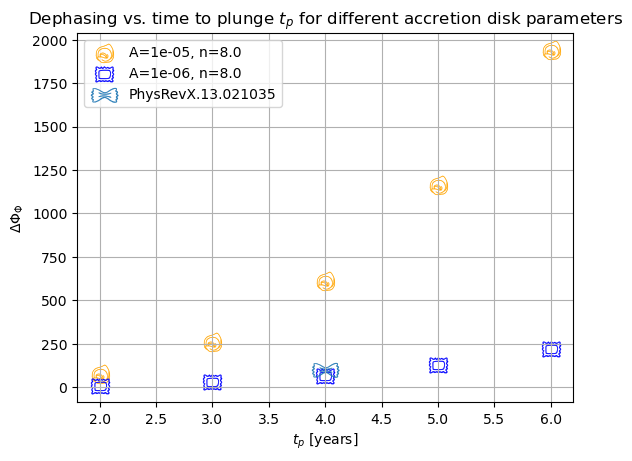

In [10]:
plt.title("Dephasing vs. time to plunge $t_p$ for different accretion disk parameters")
plt.scatter(
    results["orange"][:, 0],
    results["orange"][:, 1],
    color="orange",
    marker=markers.tortellini,
    label=results["orange"][:, 3][2],
    s=200,
    linewidth=0.2,
)
plt.scatter(
    results["blue"][:, 0],
    results["blue"][:, 1],
    color="blue",
    marker=markers.ravioli,
    label=results["blue"][:, 3][2],
    s=200,
    linewidth=0.2,
)
# plt.ylim(1e-3, 1e6)
plt.ylabel(r"$\Delta \Phi_{\Phi}$")
plt.xlabel("$t_p$ [years]")
plt.grid()
# import values from https://dx.doi.org/10.1103/PhysRevX.13.021035 fig 1
plt.scatter(
    4,
    1e2, 
    marker=markers.farfalle,
    label="PhysRevX.13.021035",  # achieved, for the same EMRI, with A=0.2e-5 (Fig. 1)
    s=400,
    linewidth=0.2,
)
plt.legend()
plt.show()

The dephasing $\Delta \Phi_{\Phi}$ obtained from the difference between the final orbital phase of an evolution with and without migration torques in an accretion disk in the $\alpha-$ (Shakura-Sunyaev) model. The obtained value in previous work for $t_p=4 yr$ is shown in the Figure as a farfalla pasta (see fig 1 of [PhysRevX.13.021035](https://dx.doi.org/10.1103/PhysRevX.13.021035)).

*Now it's your turn!*

Option 1 (astro): Write a function for the amplitude $A$ that takes as input the disk viscosity and accretion rate, as predicted by the model discussed in class. Explore for what disk parameters you can get a dephasing of order $10$.

Option 2 (waveform): Plot and compare the waveform generated by the accretion-disk trajectory and the vacuum trajectory (see waveform section of this tutorial).

### Environment: boson cloud, interaction: dynamical friction

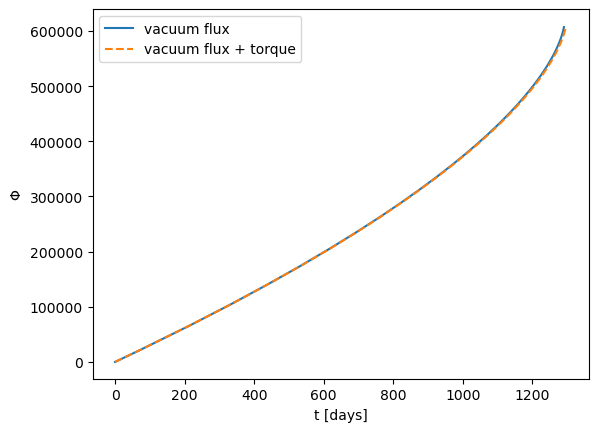

In [11]:
# Dissipation of energy and angular momentum due to migration torques in an accretion disk
# following Eq(2.2) of https://dx.doi.org/10.1103/PhysRevX.13.021035

class KerrEccEqFluxEnvironment(KerrEccEqFlux):
    def modify_rhs(self, ydot, y):
        # accretion disk torque 
        LdotAcc = (
            self.additional_args[0] # dimensionless accretion disk torque strength
            * pow(y[0] / 10.0, self.additional_args[1]) # power-law dependence on p, with index given by additional_args[1]
            * 32.0 # Ldot_GW 
            / 5.0
            * pow(y[0], -7.0 / 2.0)
        )
        # standard expression for dL/dp in Kerr
        dL_dp = (
            -3 * pow(a, 3)
            + pow(a, 2) * (8 - 3 * y[0]) * np.sqrt(y[0])
            + (-6 + y[0]) * pow(y[0], 2.5)
            + 3 * a * y[0] * (-2 + 3 * y[0])
        ) / (2.0 * pow(2 * a + (-3 + y[0]) * np.sqrt(y[0]), 1.5) * pow(y[0], 1.75)) 
        # transform back to pdot from Ldot and add GW contribution
        ydot[0] += LdotAcc / dL_dp

# same as https://dx.doi.org/10.1103/PhysRevX.13.021035
m1 = 1e6
m2 = 5e1
a = 0.9
p0 = 15.0
# assume circular orbits, for extension to eccentricity see https://arxiv.org/pdf/2411.03436
e0 = 0.0
xI0 = 1.0
T = 4.0
# disk torque parameters
A = 1e-3 # unphisically large, for demonstration purposes only; realistic values would be much smaller, e.g. 1e-10 or less for a thin disk with a low-mass secondary
power_law_index = 11/2 # dynamical friction in boson cloud

traj = EMRIInspiral(func=KerrEccEqFlux, integrate_constants_of_motion=False)
flux = traj(m1, m2, a, p0, e0, xI0, T=T, dt=2.0)

traj_bosoncloud = EMRIInspiral(func=KerrEccEqFluxEnvironment, integrate_constants_of_motion=False)
flux_bosoncloud = traj_bosoncloud(m1, m2, a, p0, e0, xI0, A, power_law_index, T=T, dt=2.0)

plt.plot(flux[0] / 86400, flux[4], label="vacuum flux")
plt.plot(flux_bosoncloud[0] / 86400, flux_bosoncloud[4], label="vacuum flux + torque", ls="--")
plt.ylabel(r"$\Phi$")
plt.xlabel("t [days]")

plt.legend()
plt.show()

We can compute the dephasing between the two models as a function of the observation time (assuming they all plunge) and for different values of the boson cloud torque amplitude.

In [12]:
# Interpolate and compare the two trajectories
from scipy.interpolate import interp1d
from few.utils.utility import get_p_at_t
from few.utils.constants import YRSID_SI
from pastamarkers import markers
import time

traj_args = [m1, m2, a, e0, xI0]
traj_kwargs = {}
t_out = 1.5
results = {"orange": [], "blue": []}
set_up =zip(
    [1.e-3, 1.e-4],
    [power_law_index, power_law_index],
    [markers.tortellini, markers.ravioli],
    ["orange", "blue"],
)
for A, n, marker, col in set_up:
    for t_out in [2.0, 3.0, 4.0, 5.0, 6.0]:
        # Obtain the initial p value for the desired trajectory duration, see below for futher explanations
        p0_new = get_p_at_t(
            traj,
            t_out,
            traj_args,
            index_of_a=2,
            index_of_p=3,
            index_of_e=4,
            index_of_x=5,
            traj_kwargs=traj_kwargs,
            xtol=1e-12,
            rtol=1e-12,
        )
        print(
            "p0_new = {} will create a waveform that is {} years long, given the other input parameters.".format(
                p0_new, t_out
            )
        )

        print("disk torque amplitude: {}".format(A))

        T = 10.0
        # T = t_out
        tic = time.time() # uncomment if you want to time the trajectory generation
        flux = traj(m1, m2, a, p0_new, e0, xI0, T=T, dt=10.0)
        toc = time.time()
        print("Time taken for trajectory:", toc - tic)
        tic = time.time()
        flux_bosoncloud = traj_bosoncloud(m1, m2, a, p0_new, e0, xI0, A, power_law_index, T=T, dt=10.0)
        toc = time.time()
        print("Time taken for flux_bosoncloud:", toc - tic)

        #we interpolate Phi_phi as a function of time
        interp_flux_bosoncloud = interp1d(flux_bosoncloud[0], flux_bosoncloud[4]) 
        interp_flux = interp1d(flux[0], flux[4])

        if t_out == 4.0:
            label = f"A={A}, n={n}"
        else:
            label = None

        # use the shortest trajectory as the reference
        t_f = flux[0][-1]
        delta_phi = interp_flux(t_f) - interp_flux_bosoncloud(t_f)
        results[col].append((t_f / YRSID_SI, delta_phi, marker, label, col, toc - tic))

for A, n, marker, col in zip(
    [1.e-5, 0.1e-5],
    [8.0, 8.0],
    [markers.tortellini, markers.ravioli],
    ["orange", "blue"],
):
    results[col] = np.array(results[col])

p0_new = 12.956503064982508 will create a waveform that is 2.0 years long, given the other input parameters.
disk torque amplitude: 0.001
Time taken for trajectory: 0.038352012634277344
Time taken for flux_bosoncloud: 0.04483509063720703
p0_new = 14.381991245381247 will create a waveform that is 3.0 years long, given the other input parameters.
disk torque amplitude: 0.001
Time taken for trajectory: 0.04298090934753418
Time taken for flux_bosoncloud: 0.04919099807739258
p0_new = 15.485924101358679 will create a waveform that is 4.0 years long, given the other input parameters.
disk torque amplitude: 0.001
Time taken for trajectory: 0.0422360897064209
Time taken for flux_bosoncloud: 0.05107307434082031
p0_new = 16.399186063133012 will create a waveform that is 5.0 years long, given the other input parameters.
disk torque amplitude: 0.001
Time taken for trajectory: 0.04214596748352051
Time taken for flux_bosoncloud: 0.04905080795288086
p0_new = 17.184489076035767 will create a waveform t

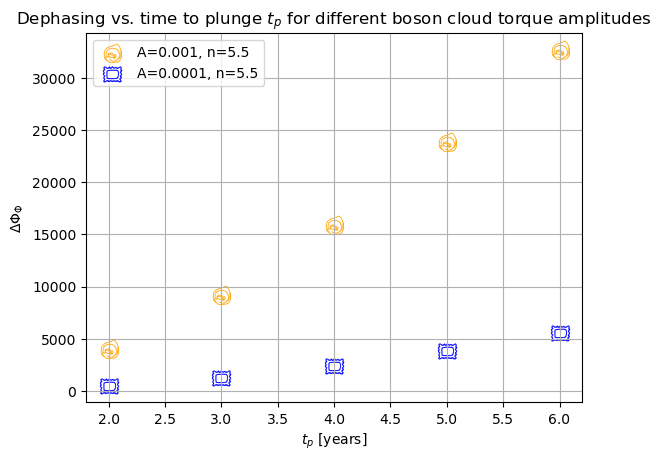

In [13]:
plt.title("Dephasing vs. time to plunge $t_p$ for different boson cloud torque amplitudes")
plt.scatter(
    results["orange"][:, 0],
    results["orange"][:, 1],
    color="orange",
    marker=markers.tortellini,
    label=results["orange"][:, 3][2],
    s=200,
    linewidth=0.2,
)
plt.scatter(
    results["blue"][:, 0],
    results["blue"][:, 1],
    color="blue",
    marker=markers.ravioli,
    label=results["blue"][:, 3][2],
    s=200,
    linewidth=0.2,
)
# plt.ylim(1e-3, 1e6)
plt.ylabel(r"$\Delta \Phi_{\Phi}$")
plt.xlabel("$t_p$ [years]")
plt.grid()
plt.legend()
plt.show()

*Now it's your turn!*

Option 1 (fundamental physics): Write a function for the amplitude $A$ that takes as input the boson mass, and boson cloud mass.

Option 2: The boson cloud produces a torque with a different power-law index. Does this influence the type of EMRI that will produce the best constraints? Try plotting the dephasing for both effects for different mass ratios, fixing the observation time before plunge. 